## Exercício 1

In [1]:
# --- Célula de Configuração de Ambiente ---
import pyarrow
from sqlalchemy import create_engine, text
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys
import subprocess

# Lista de bibliotecas necessárias
bibliotecas = ['pandas', 'sqlalchemy', 'psycopg2-binary',
               'matplotlib', 'seaborn', 'pyarrow']


def instalar_e_importar(lista_libs):
    for lib in lista_libs:
        try:
            __import__(lib.split('-')
                       [0].replace('psycopg2-binary', 'psycopg2'))
        except ImportError:
            print(f"Instalando {lib}...")
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", lib])
    print("Todas as bibliotecas estão prontas!")


instalar_e_importar(bibliotecas)

# Importações principais

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
print("Ambiente configurado com sucesso.")

Todas as bibliotecas estão prontas!
Ambiente configurado com sucesso.


In [2]:
from database_connector import BancoDeDados

from sqlalchemy import text

# Instancia a classe (garanta que a célula com a classe já foi executada)
banco = BancoDeDados()

print("--- Testando Conexões com o Banco de Dados ---")

# 1. Testando a engine_init (banco padrão 'postgres')
try:
    with banco.engine_init.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("[OK] Conexão com o banco padrão 'postgres' estabelecida com sucesso!")
except Exception as e:
    print(f"[ERRO] Falha ao conectar na engine_init: {e}")

# 2. Testando a engine_dw (banco 'dw_covid')
try:
    with banco.engine_dw.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("[OK] Conexão com o banco 'dw_covid' estabelecida com sucesso!")
except Exception as e:
    print(f"[ERRO] Falha ao conectar na engine_dw: {e}")

--- Testando Conexões com o Banco de Dados ---
[OK] Conexão com o banco padrão 'postgres' estabelecida com sucesso!
[OK] Conexão com o banco 'dw_covid' estabelecida com sucesso!


In [7]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import gc

path_csv = r"D:\MICRODADOS.csv"
path_parquet = r"D:\MICRODADOS.parquet"

print("Convertendo CSV para Parquet de forma nativa...")

writer = None

# Processa o CSV em blocos protegendo os 12GB de RAM livres
for chunk in pd.read_csv(
    path_csv, 
    sep=';', 
    encoding='LATIN1', 
    low_memory=False, 
    chunksize=100000
):
    # Converte o DataFrame do Pandas em uma Tabela do PyArrow nativa
    table = pa.Table.from_pandas(chunk, preserve_index=False)
    
    # Inicializa o gravador no primeiro bloco
    if writer is None:
        writer = pq.ParquetWriter(path_parquet, table.schema, compression='snappy')
    
    # Grava o bloco atual diretamente no arquivo
    writer.write_table(table)
    
    # Limpa a memória do bloco processado
    del chunk, table
    gc.collect()

# Fecha o arquivo Parquet após terminar todos os blocos
if writer is not None:
    writer.close()

print("[SUCESSO] Arquivo MICRODADOS.parquet gerado sem erros!")

Convertendo CSV para Parquet de forma nativa...
[SUCESSO] Arquivo MICRODADOS.parquet gerado sem erros!


In [8]:
import pandas as pd
import pyarrow.parquet as pq
from database_connector import BancoDeDados

db = BancoDeDados()
path_parquet = r"D:\MICRODADOS.parquet"

print("Lendo Parquet nativamente e calculando nulos...")

# Lê usando o motor puro do PyArrow, ignorando o bug do Pandas
table = pq.read_table(path_parquet)
df_parquet = table.to_pandas()

null_counts = df_parquet.isnull().sum()
total_linhas = len(df_parquet)
null_percentages = (null_counts / total_linhas) * 100

report_df = pd.DataFrame({
    'Coluna CSV': null_counts.index,
    'Qtd Nulos': null_counts.values,
    'Percentual Nulos (%)': null_percentages.values
})
report_df = report_df.sort_values(by='Percentual Nulos (%)', ascending=False).reset_index(drop=True)

db.salvar_dataframe(report_df, nome_tabela='relatorio_nulos_covid', if_exists='replace')

print("\n--- Top 15 Colunas com mais valores nulos ---")
print(report_df.head(15).to_string(index=False))

Lendo Parquet nativamente e calculando nulos...
[OK] Tabela "relatorio_nulos_covid" populada via COPY (45 linhas).

--- Top 15 Colunas com mais valores nulos ---
            Coluna CSV  Qtd Nulos  Percentual Nulos (%)
             DataObito    5164081             99.549125
   DataColetaSorologia    5087404             98.071006
DataColetaSorologiaIGG    5040722             97.171107
     DataColeta_RT_PCR    3574301             68.902586
 DataColetaTesteRapido    1937335             37.346433
      DataEncerramento     225547              4.347919
                Bairro      44822              0.864044
       DataNotificacao          0              0.000000
          DataCadastro          0              0.000000
         Classificacao          0              0.000000
              Evolucao          0              0.000000
   CriterioConfirmacao          0              0.000000
       DataDiagnostico          0              0.000000
     StatusNotificacao          0              0.00000

## Exercício 2

In [11]:
import pandas as pd
import pyarrow.parquet as pq
import gc
from database_connector import BancoDeDados

db = BancoDeDados()
banco_pronto = db.recriar_banco_dw()

if banco_pronto:
    # 1. Cria SÓ a estrutura (schemas, tabelas, seeds) — sem ETL ainda
    db.executar_script_snowflake(r"sql\snowflake_ddl.sql")

    # 2. Carrega o Parquet para o schema STG correto
    path_parquet = r"D:\MICRODADOS.parquet"
    print("\nLendo Parquet nativamente e enviando para o banco...")
    table = pq.read_table(path_parquet)
    df_completo = table.to_pandas()
    del table
    gc.collect()

    db.salvar_dataframe(df_completo, nome_tabela='notificacao_raw', schema='stg', if_exists='replace')
    del df_completo
    gc.collect()

    # 3. SÓ AGORA roda o ETL — os dados já existem em stg.notificacao_raw
    db.executar_script_snowflake(r"sql\snowflake_etl.sql")

    print("\n[SUCESSO] Pipeline completo: estrutura criada, dados carregados e dimensões/fato populados!")

Passo 1: Gerenciando o Banco de Dados no Servidor...
[OK] Banco 'dw_covid' recriado com sucesso.

Passo 2: Lendo e corrigindo o arquivo estrutural do Snowflake...
Passo 3: Conectando diretamente no 'dw_covid' e gerando o esquema...

[SUCESSO] O modelo Snowflake foi gerado e populado com sucesso!

Lendo Parquet nativamente e enviando para o banco...
[OK] Tabela "stg"."notificacao_raw" populada via COPY (5187470 linhas).

Passo 2: Lendo e corrigindo o arquivo estrutural do Snowflake...
Passo 3: Conectando diretamente no 'dw_covid' e gerando o esquema...

[ERRO] Falha ao processar as tabelas ou carregar o CSV: ERRO:  coluna "municipio" não existe
LINE 70:         NULLIF(TRIM(municipio), ''),
                             ^
DETAIL:  Há uma coluna chamada "municipio", na tabela "dim_municipio", mas não pode ser referenciada dessa parte da consulta.


[SUCESSO] Pipeline completo: estrutura criada, dados carregados e dimensões/fato populados!


## Exercício 3


### Modelo Estrela (original)
Uma única dimensão desnormalizada `DIM_LOCALIDADE (sk_localidade, municipio, bairro, regiao, ...)`,
com redundância de dados — o nome do município se repete em cada linha de bairro.

### Modelo Floco de Neve (proposto)
Normalização em 3 níveis hierárquicos:

### Comparação: Estrela vs. Floco de Neve

| Critério | Estrela (DIM_LOCALIDADE única) | Floco de Neve (3 tabelas) |
|---|---|---|
| **Redundância** | Alta — município repetido em cada bairro | Baixa — município armazenado 1x |
| **Performance de leitura** | Melhor — menos `JOIN`s para consultas simples | Pior — exige `JOIN` extra (bairro → município → região) |
| **Manutenção** | Mais difícil — corrigir nome de município exige `UPDATE` em várias linhas | Mais fácil — corrige em 1 linha na `DIM_MUNICIPIO` |
| **Integridade** | Risco de inconsistência (mesmo município grafado diferente em linhas distintas) | Garantida por FK — só existe uma versão de cada município |
| **Espaço em disco** | Maior (strings repetidas) | Menor (chaves substitutas reutilizadas) |
| **Complexidade de ETL** | Mais simples (1 INSERT) | Mais complexa (ordem de carga: região → município → bairro) |
| **Indicado quando...** | Poucas atualizações na dimensão, prioridade em performance de consulta (BI/dashboards) | Dimensão com atualizações frequentes ou hierarquia que cresce (ex.: adicionar nível "macrorregião") |

### Conclusão prática
Para este projeto (dashboard analítico com poucas atualizações na lista de municípios/bairros),
o ganho de manutenção do floco de neve compensa o custo extra de `JOIN`, especialmente porque a
`mart.mv_resumo_municipio_mes` (Exercício 4) já pré-agrega os dados e absorve esse custo extra de
junção — a consulta final ao usuário não sente a diferença de performance.

## Exercício 4

In [13]:
from database_connector import BancoDeDados

# 1. Instancia o conector do banco (ele já conhece as credenciais)
db = BancoDeDados()

# 2. Define o caminho do script do Data Mart
SQL_MART_PATH = r"sql\mart_municipio_mes.sql"

# 3. Dispara todo o processo de criação e análise de performance
db.processar_e_testar_data_mart(SQL_MART_PATH)

Passo 1: Lendo o script de criação do Data Mart...
Passo 2: Criando a Materialized View e Índices...
[OK] Materialized View criada com sucesso no schema 'mart'.

Passo 3: Executando EXPLAIN ANALYZE na tabela Fato original (Ad-hoc)...
--- RESULTADO FATO ---
GroupAggregate  (cost=24.48..24.53 rows=1 width=258) (actual time=0.056..0.057 rows=0.00 loops=1)
  Group Key: t.ano_mes
  Buffers: shared hit=3 dirtied=1
  ->  Sort  (cost=24.48..24.49 rows=5 width=252) (actual time=0.055..0.056 rows=0.00 loops=1)
        Sort Key: t.ano_mes
        Sort Method: quicksort  Memory: 25kB
        Buffers: shared hit=3 dirtied=1
        ->  Nested Loop  (cost=9.68..24.42 rows=5 width=252) (actual time=0.051..0.052 rows=0.00 loops=1)
              Join Filter: (f.sk_data_notificacao = t.sk_tempo)
              Buffers: shared hit=3 dirtied=1
              ->  Seq Scan on dim_tempo t  (cost=0.00..1.01 rows=1 width=36) (actual time=0.010..0.010 rows=1.00 loops=1)
                    Buffers: shared hit=1
 

## Exercício 5

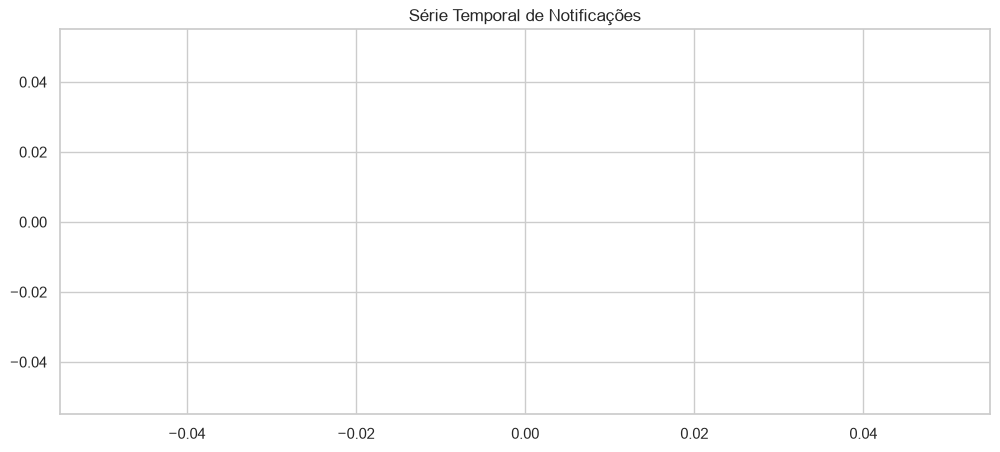

[ERRO] Falha ao executar a query: Execution failed on sql 'SELECT 
    'Pulmão' AS comorbidade, SUM(c.com_pulmao) AS total FROM dw.dim_comorbidade c 
    JOIN dw.fato_notificacao_covid f ON c.sk_comorbidade = f.sk_como WHERE f.flag_obito_covid = 1
UNION ALL
SELECT 'Cardio', SUM(c.com_cardio) FROM dw.dim_comorbidade c 
    JOIN dw.fato_notificacao_covid f ON c.sk_comorbidade = f.sk_como WHERE f.flag_obito_covid = 1
UNION ALL
SELECT 'Diabetes', SUM(c.com_diabetes) FROM dw.dim_comorbidade c 
    JOIN dw.fato_notificacao_covid f ON c.sk_comorbidade = f.sk_como WHERE f.flag_obito_covid = 1
UNION ALL
SELECT 'Obesidade', SUM(c.com_obesidade) FROM dw.dim_comorbidade c 
    JOIN dw.fato_notificacao_covid f ON c.sk_comorbidade = f.sk_como WHERE f.flag_obito_covid = 1
UNION ALL
SELECT 'Renal', SUM(c.com_renal) FROM dw.dim_comorbidade c 
    JOIN dw.fato_notificacao_covid f ON c.sk_comorbidade = f.sk_como WHERE f.flag_obito_covid = 1
ORDER BY total DESC
LIMIT 5;': (psycopg2.errors.UndefinedColumn)

KeyError: 'comorbidade'

<Figure size 800x500 with 0 Axes>

In [ ]:

def executar_query_do_arquivo(caminho_arquivo, db_connector):
    """Lê um arquivo .sql e retorna um DataFrame do Pandas."""
    with open(caminho_arquivo, 'r', encoding='utf-8') as f:
        query = f.read()

    # Supondo que seu db_connector tenha um método para ler query
    # Se não tiver, use: return pd.read_sql(query, db_connector.engine_dw)
    return db_connector.ler_tabela_query(query)

def plot_serie_temporal(df):
    plt.figure(figsize=(12, 5))
    # Ajuste 'data_completa' e 'total_notificacoes' se os nomes das colunas no seu SQL forem diferentes
    plt.plot(df['data_completa'], df['total_notificacoes'])
    plt.title('Série Temporal de Notificações')
    plt.show()


def plot_mapa_calor(df):
    plt.figure(figsize=(10, 8))
    # Transforma o DF em formato de matriz para o heatmap
    pivot = df.pivot(index='municipio', columns='mes', values='total')
    sns.heatmap(pivot, annot=False, cmap='YlGnBu')
    plt.title('Mapa de Calor por Município')
    plt.show()


def plot_piramide_etaria(df):
    # Exemplo simples de barh empilhado
    df.set_index('faixa_etaria').plot(
        kind='barh', stacked=True, figsize=(10, 6))
    plt.title('Pirâmide Etária dos Óbitos')
    plt.show()


def plot_top_comorbidades(df):
    plt.figure(figsize=(8, 5))
    plt.bar(df['comorbidade'], df['total'], color='salmon')
    plt.title('Top 5 Comorbidades em Óbitos')
    plt.show()



    # A. Série Temporal
df_serie = executar_query_do_arquivo('sql/serie_temporal.sql', db)
plot_serie_temporal(df_serie)

# B. Mapa de Calor (Uso da Materialized View)
df_heatmap = executar_query_do_arquivo('sql/mapa_de_calor.sql', db)
plot_mapa_calor(df_heatmap)

# C. Pirâmide Etária
df_piramide = executar_query_do_arquivo('sql/piramide_etaria.sql', db)
plot_piramide_etaria(df_piramide)

# D. Top-5 Comorbidades
df_comorb = executar_query_do_arquivo('sql/top_comorbidades.sql', db)
plot_top_comorbidades(df_comorb)

## Exercício 6

### 1. Novo Esquema da Tabela dw.dim_municipio
A tabela ganha campos de controle de vigência (data_inicio, data_fim) e um indicador de registro ativo (flag_atual).

Além disso, a sk_municipio continua sendo a Chave Substituta (Surrogate Key) sequencial única, garantindo que o mesmo município possa ter várias linhas no banco (uma para cada período populacional).

"CREATE TABLE dw.dim_municipio (
    -- Chave substituta garante a unicidade de cada versão histórica
    sk_municipio SERIAL PRIMARY KEY, 
    
    -- Chave de negócio (Código IBGE ou Nome do Município)
    municipio VARCHAR(100) NOT NULL,
    uf CHAR(2) DEFAULT 'ES',
    fk_regiao INT NOT NULL REFERENCES dw.dim_regiao(sk_regiao),
    
    -- O novo atributo mutável no tempo
    populacao_municipio INT,
    
    -- Campos de controle do SCD Tipo 2
    data_inicio DATE NOT NULL,      -- Quando essa versão da população começou a valer
    data_fim DATE,                  -- Quando essa versão foi substituída (NULL se for a atual)
    flag_atual BOOLEAN NOT NULL     -- TRUE para a versão ativa, FALSE para versões antigas
);"

### 2. Fluxo de Funcionamento no ETL (Lógica de Atualização)

Quando o processo de ETL rodar e detectar que a população de um município mudou no arquivo original (ex: Vila Velha mudou de 500k para 520k habitantes):

    Fecha o registro antigo: O ETL localiza a linha atual daquele município (flag_atual = TRUE), altera a data_fim para a data de ontem (ex: 2026-06-14) e muda o flag_atual para FALSE.

    Abre o registro novo: O ETL insere uma linha novinha para o município com a população atualizada, definindo data_inicio = '2026-06-15', data_fim = NULL e flag_atual = TRUE.

### 3. Impacto nas Consultas (Fato -> Dimensão)

O maior benefício do SCD Tipo 2 é a preservação da foto histórica do momento exato do evento.

    Quando o processo de carga da fato_notificacao_covid rodar, o LEFT JOIN que busca a chave do local não vai olhar apenas o nome da cidade. Ele obrigatoriamente cruzará a data da notificação com o período de vigência da dimensão.

    "SELECT 
        m.sk_municipio
    FROM stg.notificacao_raw s
    JOIN dw.dim_municipio m 
    ON m.municipio = s.municipio 
    AND s.DataNotificacao::DATE BETWEEN m.data_inicio AND COALESCE(m.data_fim, '2026-12-31'::DATE);"

## Exercício 7

In [17]:
# Instancie a classe se ainda não o fez
db = BancoDeDados()

# Chame o método passando o caminho do arquivo
db.executar_quality_gate(r"sql\quality_gate_fato.sql")

Passo 2: Criando a Stored Procedure no banco...
[OK] Stored Procedure 'dw.sp_validar_qualidade_carga' criada.

Passo 3: Executando o Quality Gate (Validação)...

[BLOQUEADO] Carga interrompida pelo Quality Gate:
Detalhe do Erro: ERRO:  coluna s.municipio não existe
LINE 2: ...pio dm_b ON dm_b.municipio = COALESCE(NULLIF(TRIM(s.municipi...
                                                             ^
HINT:  Talvez você queira fazer referência à coluna "s.Municipio".
QUERY:  SELECT COUNT(*)                       FROM stg.notificacao_raw s
    LEFT JOIN dw.dim_municipio dm_b ON dm_b.municipio = COALESCE(NULLIF(TRIM(s.municipio), ''), 'Desconhecido')
    LEFT JOIN dw.dim_bairro db ON db.bairro = COALESCE(NULLIF(TRIM(s.bairro), ''), 'Desconhecido') AND db.fk_municipio = dm_b.sk_municipio
    WHERE db.sk_bairro IS NULL
CONTEXT:  função PL/pgSQL dw.sp_validar_qualidade_carga() linha 35 em comando SQL

